<a href="https://colab.research.google.com/github/RMKEC111722203119/Condensation-Aware-Intelligent-Thermoelectric-Cooler-for-PC/blob/main/PM_Regression_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
`12# pip install pycaret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.3/66.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/1

In [ ]:
# ----------------------------------------------
#  Single-file PyCaret regression comparison
#  Drops Timestamp, Status, DewPoint
#  Predicts DHT11_Temp (°C) – change target if you like
# ----------------------------------------------
import pandas as pd


# 1. Load data
df = pd.read_csv("final5")          # <- adjust path if necessary



df.head()

,Timestamp,DHT11_Temp (°C),Humidity (%),DS18B20_Temp (°C),DewPoint (°C),Status,Core1_Temp_C,Core1_Load_pct,Core2_Temp_C,Core2_Load_pct,Package_Temp_C,Package_Power_W,CPU_Total_Load_pct,volt
0,2025-09-22 14:22:50,21.8,57.0,19.94,12.98,SAFE,23.0,20.0,19.0,20.0,25.0,5.05,100.0,3
1,2025-09-22 14:15:12,21.0,62.0,19.00,13.51,SAFE,23.0,20.0,20.0,20.0,25.0,4.97,100.0,3
2,2025-09-22 14:18:56,21.5,59.0,18.94,13.22,SAFE,24.0,20.0,19.0,20.0,24.0,5.09,100.0,3
3,2025-09-22 14:21:26,21.4,59.0,19.87,13.13,SAFE,24.0,20.0,19.0,20.0,24.0,5.06,100.0,3
4,2025-09-22 14:21:28,21.4,59.0,19.87,13.13,SAFE,24.0,20.0,19.0,20.0,24.0,5.30,100.0,3


In [ ]:
# 2. Drop non-predictive columns
df = df.drop(columns=["Timestamp", "Status", "DewPoint (°C)","CPU_Total_Load_pct"])

In [ ]:
df

,DHT11_Temp (°C),Humidity (%),DS18B20_Temp (°C),Core1_Temp_C,Core1_Load_pct,Core2_Temp_C,Core2_Load_pct,Package_Temp_C,Package_Power_W,volt
0,21.8,57.0,19.94,23.0,20.0,19.0,20.0,25.0,5.05,3
1,21.0,62.0,19.00,23.0,20.0,20.0,20.0,25.0,4.97,3
2,21.5,59.0,18.94,24.0,20.0,19.0,20.0,24.0,5.09,3
3,21.4,59.0,19.87,24.0,20.0,19.0,20.0,24.0,5.06,3
4,21.4,59.0,19.87,24.0,20.0,19.0,20.0,24.0,5.30,3
...,...,...,...,...,...,...,...,...,...,...
340,39.5,48.0,30.75,62.0,100.0,62.0,100.0,62.0,14.41,11
341,39.5,48.0,30.81,62.0,100.0,62.0,100.0,62.0,15.03,11
342,39.5,47.0,30.75,62.0,100.0,63.0,100.0,63.0,16.62,11
343,39.5,48.0,30.81,63.0,100.0,62.0,100.0,63.0,15.43,11


In [ ]:
!pip install -q "pycaret[full]==3.3.2" pandas numpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 55.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.5/177.5 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 81.8 MB/s

In [ ]:
from pycaret.classification import *
exp_name = setup(data = df,  target = 'volt')


RuntimeError: ('Pycaret only supports python 3.9, 3.10, 3.11. Your actual Python version: ', sys.version_info(major=3, minor=12, micro=12, releaselevel='final', serial=0), 'Please DOWNGRADE your Python version.')

In [ ]:
# 3. Choose target
target = "DHT11_Temp (°C)"

# 4. PyCaret setup
reg = setup(
    data=df,
    target=target,
    train_size=0.8,
    session_id=42,
    normalize=True,
    transformation=True,
    silent=True,
    verbose=False
)

# 5. Compare models (5-fold CV, sorted by RMSE)
best = compare_models(
    include=["lr", "ridge", "lasso", "en", "lar", "llar",
             "omp", "br", "ard", "par", "rf", "et",
             "gbr", "mlp", "xgboost", "lightgbm"],
    fold=5,
    sort="RMSE"
)


In [ ]:
!python --version

Python 3.12.12


In [ ]:
!apt-get --purge remove python3.12 !apt-get autoremove !apt-get clean

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package !apt-get
E: Couldn't find any package by glob '!apt-get'
E: Unable to locate package autoremove
E: Unable to locate package !apt-get
E: Couldn't find any package by glob '!apt-get'
E: Unable to locate package clean


In [ ]:
# ---------------------------------------------------------
#  Sklearn-only regression comparison
#  Drops Timestamp, Status, DewPoint
#  Predicts DHT11_Temp (°C)  – change target if you like
# ---------------------------------------------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib


X = df.drop(columns=['volt'])
y = df['volt']

# 3. Train / test split --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Algorithms to compare ----------------------------------------------
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, Lars, LassoLars,
    OrthogonalMatchingPursuit, BayesianRidge, ARDRegression
)
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor          # pip install xgboost
from lightgbm import LGBMRegressor        # pip install lightgbm

models = {
    'LR'          : LinearRegression(),
    'Ridge'       : Ridge(alpha=1.0),
    'Lasso'       : Lasso(alpha=0.1),
    'ElasticNet'  : ElasticNet(alpha=0.1, l1_ratio=0.5),
    'Lars'        : Lars(),
    'LassoLars'   : LassoLars(alpha=0.1),
    'OMP'         : OrthogonalMatchingPursuit(),
    'BayesianRidge': BayesianRidge(),
    'ARD'         : ARDRegression(),
    'SVR'         : SVR(kernel='rbf', C=100, gamma='scale'),
    'RandomForest': RandomForestRegressor(n_estimators=500, random_state=42),
    'ExtraTrees'  : ExtraTreesRegressor(n_estimators=500, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=500, random_state=42),
    'XGBoost'     : XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=42),
    'LightGBM'    : LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
}

# 5. Evaluate -------------------------------------------------------------
results = []

for name, model in models.items():
    pipe = Pipeline([
        ('scale', StandardScaler()),
        ('reg', model)
    ])

    # 5-fold CV RMSE
    rmse = -cross_val_score(pipe, X_train, y_train,
                            scoring='neg_root_mean_squared_error',
                            cv=5, n_jobs=-1).mean()

    r2 = cross_val_score(pipe, X_train, y_train,
                         scoring='r2', cv=5, n_jobs=-1).mean()

    results.append({'model': name, 'RMSE': rmse, 'R2': r2})

# 6. Leaderboard ----------------------------------------------------------
leaderboard = pd.DataFrame(results).sort_values('RMSE')
print(leaderboard)

# 7. Refit best model on full training set --------------------------------
best_name = leaderboard.iloc[0]['model']
best_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('reg', models[best_name])
])
best_pipe.fit(X_train, y_train)

# 8. Test-set performance -------------------------------------------------
test_rmse = mean_squared_error(y_test, best_pipe.predict(X_test), squared=False)
test_r2   = r2_score(y_test, best_pipe.predict(X_test))
print(f"\nBest model: {best_name}")
print(f"Test RMSE : {test_rmse:.4f}")
print(f"Test R²   : {test_r2:.4f}")

# # 9. Save -----------------------------------------------------------------
# joblib.dump(best_pipe, 'best_model.pkl')
# print("Saved best_model.pkl")

               model         RMSE            R2
11        ExtraTrees     0.657449  9.396610e-01
12  GradientBoosting     0.847123  9.033604e-01
10      RandomForest     0.934607  8.859215e-01
13           XGBoost     0.986306  8.527768e-01
14          LightGBM     1.037369  8.561788e-01
9                SVR     1.344128  7.673087e-01
6                OMP     2.769480  3.244128e-02
3         ElasticNet     5.954542 -9.040406e+00
2              Lasso     7.485073 -1.782126e+01
5          LassoLars     7.492586 -1.787303e+01
1              Ridge    17.934892 -1.628310e+02
7      BayesianRidge    19.125660 -1.887632e+02
0                 LR    20.276719 -2.085526e+02
8                ARD    20.644328 -2.231979e+02
4               Lars  4658.143418 -1.180687e+07

Best model: ExtraTrees
Test RMSE : 0.4294
Test R²   : 0.9772


Extra-Trees  –  RMSE: 0.429 °C   MAE: 0.228 °C   R²: 0.977


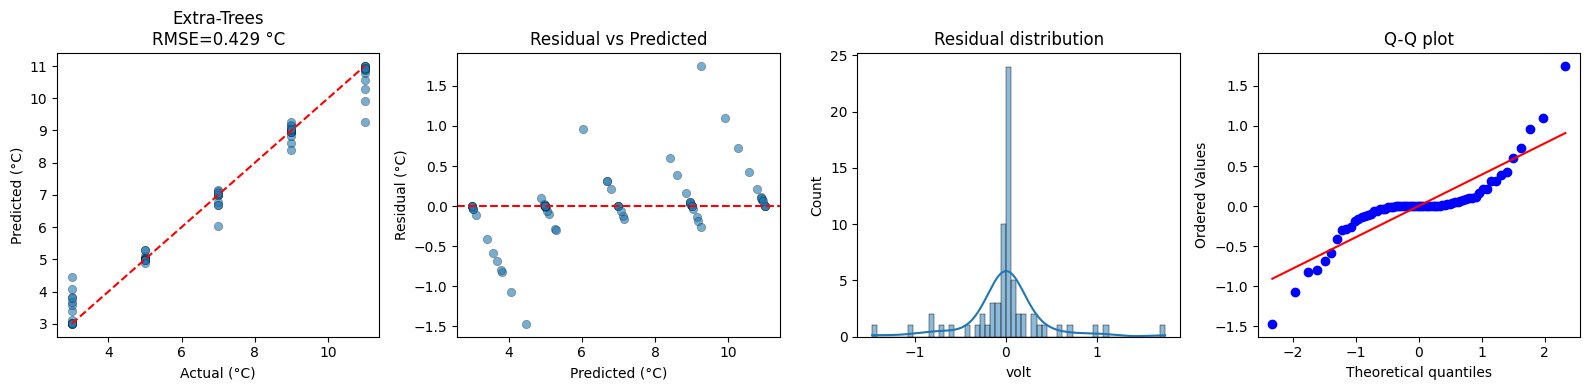

In [ ]:
# ---------------------------------------------------------
# Retrain Extra-Trees regressor and produce the 4-panel
# regression-diagnostic plot (like confusion matrix)
# ---------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import scipy.stats as stats


X = df.drop(columns=['volt'])
y = df['volt']

# 2. Train-test split -----------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Build pipeline (scaling + Extra-Trees) -------------------------------
et_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('et', ExtraTreesRegressor(
        n_estimators=500,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

et_pipe.fit(X_train, y_train)

# 4. Predict & metrics ----------------------------------------------------
y_pred = et_pipe.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae  = mean_absolute_error(y_test, y_pred)
r2   = et_pipe.score(X_test, y_test)

print(f'Extra-Trees  –  RMSE: {rmse:.3f} °C   MAE: {mae:.3f} °C   R²: {r2:.3f}')

# 5. Diagnostic plots -----------------------------------------------------
resid = y_test - y_pred

fig, ax = plt.subplots(1, 4, figsize=(16, 4))

# 1. Predicted vs Actual
ax[0].scatter(y_test, y_pred, alpha=0.6, edgecolors='k', lw=0.3)
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax[0].set_xlabel('Actual (°C)')
ax[0].set_ylabel('Predicted (°C)')
ax[0].set_title(f'Extra-Trees\nRMSE={rmse:.3f} °C')

# 2. Residual vs Predicted
ax[1].scatter(y_pred, resid, alpha=0.6, edgecolors='k', lw=0.3)
ax[1].axhline(0, color='r', linestyle='--')
ax[1].set_xlabel('Predicted (°C)')
ax[1].set_ylabel('Residual (°C)')
ax[1].set_title('Residual vs Predicted')

# 3. Histogram of residuals
sns.histplot(resid, kde=True, ax=ax[2])
ax[2].set_title('Residual distribution')

# 4. Q-Q plot
stats.probplot(resid, dist="norm", plot=ax[3])
ax[3].set_title('Q-Q plot')

plt.tight_layout()
plt.show()